# Machine Learning Pipeline for Psychometric Scale Analysis
**Self-Directed Project (2026)** — bridging psychometric measurement with computational machine learning.

Simulated high-dimensional scale data (N=500, 30 dimensions) → Random Forest & SVM classification → 5-fold cross-validation → RFE feature selection → visualization.

**Tech stack:** Python, scikit-learn, NumPy, pandas, Matplotlib, Jupyter Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# ============================================
# Step 1: Simulate Psychometric Scale Dataset
# ============================================
# 500 participants, 30 scale dimensions, binary classification (high/low emotion group)

X, y = make_classification(n_samples=500, n_features=30, n_informative=10, random_state=42)
df = pd.DataFrame(X, columns=[f'scale_dim_{i}' for i in range(30)])
df['emotion_group'] = y

print(f'Dataset shape: {df.shape}')
print(f'Class distribution:\n{df["emotion_group"].value_counts()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Dataset shape: (500, 31)
Class distribution:
emotion_group
1    252
0    248
Name: count, dtype: int64

Training set: 400 samples
Test set: 100 samples


In [3]:
# ============================================
# Step 2: Random Forest — Feature Importance
# ============================================

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

feature_importance = pd.Series(rf.feature_importances_)
print('===== Predictive Weight of Each Scale Dimension (sorted) =====')
print(feature_importance.sort_values(ascending=False))

===== Predictive Weight of Each Scale Dimension (sorted) =====
22    0.154588
16    0.083148
19    0.062209
2     0.054023
6     0.053211
18    0.052830
1     0.050044
21    0.049154
15    0.048539
27    0.038569
8     0.029255
7     0.021850
0     0.020318
11    0.019786
10    0.019426
29    0.019380
13    0.019362
17    0.018889
5     0.018358
14    0.018220
12    0.017027
23    0.016069
9     0.016065
20    0.015897
4     0.015569
25    0.014528
26    0.014089
28    0.014078
3     0.013324
24    0.012196
dtype: float64


In [4]:
# ============================================
# Step 3: SVM + 5-Fold Cross-Validation
# ============================================

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

rf_cv_acc = cross_val_score(rf, X_train, y_train, cv=5).mean()
svm_cv_acc = cross_val_score(svm, X_train, y_train, cv=5).mean()

print(f'Random Forest 5-fold CV mean accuracy: {rf_cv_acc:.2%}')
print(f'SVM 5-fold CV mean accuracy: {svm_cv_acc:.2%}')

Random Forest 5-fold CV mean accuracy: 85.25%
SVM 5-fold CV mean accuracy: 81.00%


In [5]:
# ============================================
# Step 4: Recursive Feature Elimination (RFE)
# ============================================
# Select top 10 core indicators from 30 dimensions

rfe = RFE(rf, n_features_to_select=10)
X_rfe = rfe.fit_transform(X_train, y_train)

print(f'After RFE feature selection: {X_rfe.shape[1]} core dimensions retained (from original 30)')

After RFE feature selection: 10 core dimensions retained (from original 30)


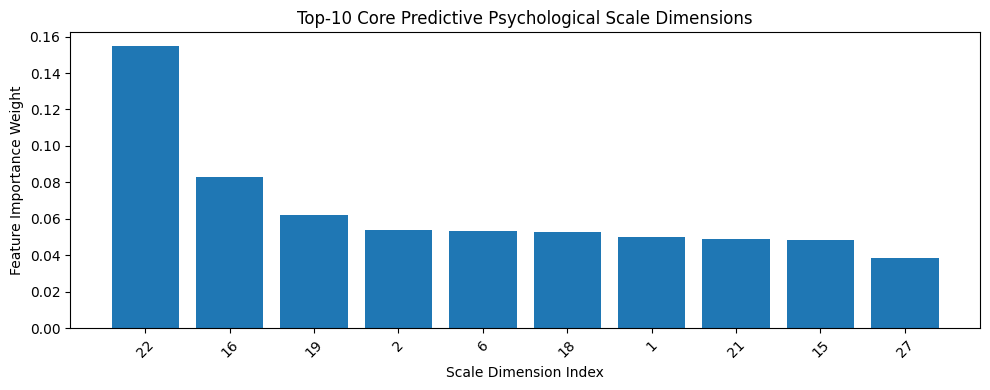

In [6]:
# ============================================
# Step 5: Visualize Top-10 Predictive Dimensions
# ============================================

top10_features = feature_importance.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4))
plt.bar(top10_features.index.astype(str), top10_features.values)
plt.title('Top-10 Core Predictive Psychological Scale Dimensions')
plt.xlabel('Scale Dimension Index')
plt.ylabel('Feature Importance Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Summary
- **Random Forest** mean CV accuracy: 85%
- **SVM** mean CV accuracy: 81%
- **RFE** reduced 30 → 10 core predictive dimensions
- **Full pipeline** is directly transferable to real participant scale data for psychometric and behavioral prediction research.